<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/Part1_task2_spiral_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 1, Task 2: Modelling a 2D Spiral with WGAN-GP

The 2D spiral is a challenging target: a connected, self-overlapping manifold.
A vanilla GAN tends to suffer **mode collapse** on this shape (the generator
covers only one small region). We therefore use **WGAN-GP** (Wasserstein GAN
with gradient penalty), which is far more stable and resists mode collapse.

References: Arjovsky et al. (2017), Gulrajani et al. (2017).

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Real data: the 2D spiral

We sample spiral points in polar form (radius grows with angle), convert to
Cartesian (x, y), and add small Gaussian noise to give the spiral thickness.

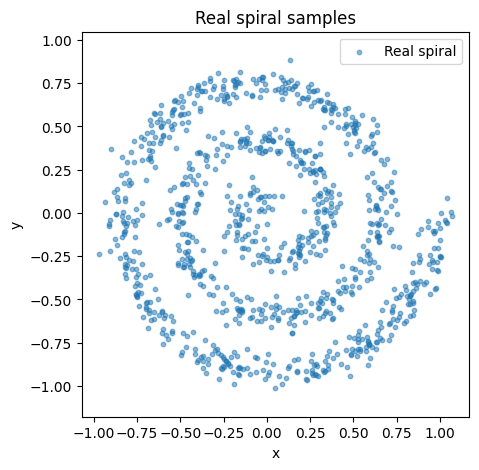

In [2]:
def sample_real_spiral_data(n_samples, n_turns=3, noise=0.05):
    """
    Generate real samples from a 2D spiral.

    Radius grows linearly with angle; (r, theta) is converted to (x, y).
    sqrt(uniform) spreads points evenly along the spiral rather than
    bunching near the centre. Gaussian noise adds thickness.

    Returns a tensor of shape (n_samples, 2).
    """
    theta = np.sqrt(np.random.uniform(0, 1, n_samples)) * (2 * np.pi * n_turns)
    r = theta / (2 * np.pi * n_turns)

    x = r * np.cos(theta) + noise * np.random.randn(n_samples)
    y = r * np.sin(theta) + noise * np.random.randn(n_samples)

    data = np.stack([x, y], axis=1).astype(np.float32)
    return torch.from_numpy(data)


# Preview the target distribution
sample = sample_real_spiral_data(1000).numpy()
plt.figure(figsize=(5, 5))
plt.scatter(sample[:, 0], sample[:, 1], s=10, alpha=0.5, label="Real spiral")
plt.title("Real spiral samples")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.legend()
plt.show()

## 2. Models: Generator and Critic

- **Generator**: maps a noise vector to a 2D point.
- **Critic** (WGAN's discriminator): outputs an *unbounded score*, not a
  probability — so **no sigmoid**. We use `LayerNorm`, the recommended
  normalisation for WGAN-GP.

In [3]:
class Generator(nn.Module):
    """Maps a noise vector z to a 2D point (x, y)."""
    def __init__(self, noise_dim=16, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, z):
        return self.net(z)


class Critic(nn.Module):
    """WGAN critic: outputs a real-valued score (no sigmoid)."""
    def __init__(self, in_dim=2, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

## 3. WGAN-GP training

The **gradient penalty** enforces the 1-Lipschitz constraint the Wasserstein
distance requires, by pushing the critic's gradient norm toward 1 at random
points between real and fake samples. The critic is updated `n_critic` times
per generator update — this balance is what makes WGAN-GP stable and resistant
to mode collapse.

In [7]:
def gradient_penalty(critic, real_data, fake_data):
    """WGAN-GP gradient penalty (pushes critic gradient norm toward 1)."""
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1, device=device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)

    scores = critic(interpolated)
    gradients = torch.autograd.grad(
        outputs=scores, inputs=interpolated,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True
    )[0]
    grad_norm = gradients.norm(2, dim=1)
    return ((grad_norm - 1) ** 2).mean()


def coverage_score(generator, sample_real_fn, noise_dim, n=1000):
    """
    Rough measure of how well generated points cover the real distribution:
    average nearest-neighbour distance from real points to generated points.
    Lower = generated samples spread across the real data better.
    Used to checkpoint the best generator state during training.
    """
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n, noise_dim, device=device)
        fake = generator(z).cpu()
    real = sample_real_fn(n)
    # distance from each real point to nearest fake point
    dists = torch.cdist(real, fake)          # (n_real, n_fake)
    nn_dist = dists.min(dim=1).values.mean()  # avg nearest-neighbour distance
    generator.train()
    return nn_dist.item()


def train_wgan_gp(generator, critic, sample_real_fn, noise_dim=16,
                  n_epochs=4000, batch_size=256, lr=1e-4,
                  n_critic=2, lambda_gp=10.0, log_every=1000):
    """
    Trains a WGAN-GP and keeps the best-covering generator state (via
    coverage_score) so we evaluate the best model, not just the final one.
    Returns loss histories and the best generator state_dict.
    """
    import copy
    generator.to(device); critic.to(device)

    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.0, 0.9))
    opt_c = torch.optim.Adam(critic.parameters(), lr=lr, betas=(0.0, 0.9))

    g_losses, c_losses = [], []
    best_score = float("inf")
    best_state = copy.deepcopy(generator.state_dict())

    for epoch in range(n_epochs):
        for _ in range(n_critic):
            real_data = sample_real_fn(batch_size).to(device)
            z = torch.randn(batch_size, noise_dim, device=device)
            fake_data = generator(z).detach()

            c_loss = -(critic(real_data).mean() - critic(fake_data).mean()) \
                     + lambda_gp * gradient_penalty(critic, real_data, fake_data)

            opt_c.zero_grad(); c_loss.backward(); opt_c.step()

        z = torch.randn(batch_size, noise_dim, device=device)
        g_loss = -critic(generator(z)).mean()
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        g_losses.append(g_loss.item()); c_losses.append(c_loss.item())

        # Checkpoint the best-covering generator every 100 epochs
        if epoch % 100 == 0:
            score = coverage_score(generator, sample_real_fn, noise_dim)
            if score < best_score:
                best_score = score
                best_state = copy.deepcopy(generator.state_dict())

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | Critic: {c_loss.item():.4f} "
                  f"| G: {g_loss.item():.4f} | best coverage: {best_score:.4f}")

    return g_losses, c_losses, best_state

In [5]:
def plot_real_vs_generated(generator, sample_real_fn, noise_dim=16,
                            n_samples=1000, title="Real vs Generated"):
    """Overlays real samples and generator output for visual comparison."""
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, noise_dim, device=device)
        fake_data = generator(z).cpu().numpy()
    real_data = sample_real_fn(n_samples).numpy()
    generator.train()

    plt.figure(figsize=(6, 6))
    plt.scatter(real_data[:, 0], real_data[:, 1], s=10, alpha=0.5, label="Real")
    plt.scatter(fake_data[:, 0], fake_data[:, 1], s=10, alpha=0.5, label="Generated")
    plt.legend(); plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")
    plt.axis("equal")
    plt.show()


def plot_losses(g_losses, c_losses, title="Training Losses"):
    """Plots generator and critic loss curves."""
    plt.figure(figsize=(6, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(c_losses, label="Critic loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend()
    plt.show()

## 4. Train and evaluate

We now train the WGAN-GP on the spiral and inspect two things: the loss curves
and, more importantly, the overlay of real vs. generated samples. For GANs the
sample plot is the true test of success — loss values alone say little about
output quality.

Epoch 1000/4000 | Critic: 1.1070 | G: -1.8848 | best coverage: 0.3402
Epoch 2000/4000 | Critic: 0.6412 | G: -1.2405 | best coverage: 0.3402
Epoch 3000/4000 | Critic: 0.2477 | G: -0.3464 | best coverage: 0.0649
Epoch 4000/4000 | Critic: 0.5441 | G: 1.0484 | best coverage: 0.0649


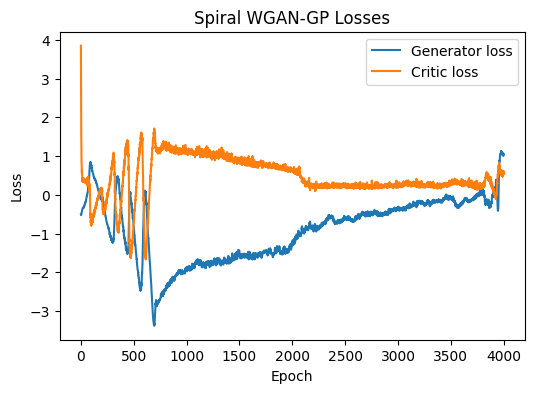

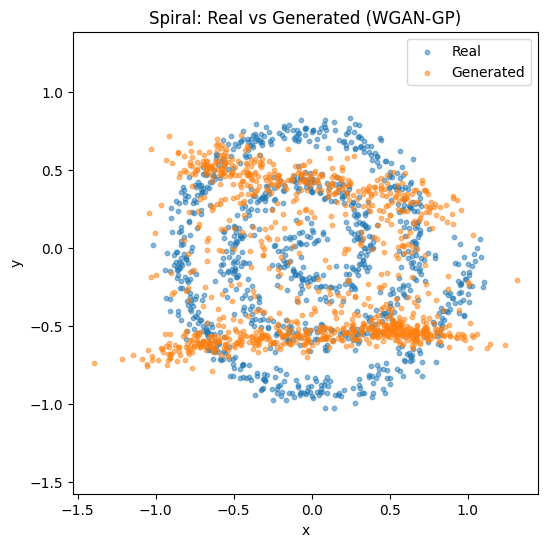

In [8]:
NOISE_DIM = 16
torch.manual_seed(0)

gen_spiral = Generator(noise_dim=NOISE_DIM, hidden_dim=128, out_dim=2)
critic_spiral = Critic(in_dim=2, hidden_dim=128)

g_losses, c_losses, best_state = train_wgan_gp(
    gen_spiral, critic_spiral, sample_real_spiral_data,
    noise_dim=NOISE_DIM, n_epochs=4000, lr=1e-4, n_critic=2
)

# Load the best-covering generator state before plotting
gen_spiral.load_state_dict(best_state)

plot_losses(g_losses, c_losses, title="Spiral WGAN-GP Losses")
plot_real_vs_generated(gen_spiral, sample_real_spiral_data,
                       noise_dim=NOISE_DIM, title="Spiral: Real vs Generated (WGAN-GP)")